# ME 323 Module 1 — Choosing the Ground-Truth Model and the Noise Level
### Faculty notebook (staff only — not for students)

The Module 1 student notebooks "test" two class designs against a frozen
**ground-truth (GT) model** — a surrogate for reality, fit to every beam we
have actually broken. This notebook is the receipts for that model: the full
test campaign, the noise level the repeats support, the candidate model
formulations, how they were scored, and why the winner won. It is
self-contained — it loads the two committed campaign CSVs from GitHub and
reproduces the frozen decision end-to-end (≈10–15 min run time; numpy, pandas,
scikit-learn, matplotlib).

> **Update 2026-07-17 — the shear model is under review.** The GT winner
> `gpf_sw_matern` is *physics-informed*: it takes `log P_phys` as an input
> feature, so the failure-mode physics — including the shear model — is baked
> into the ground truth. `ME323_Module1_Shear_Model_Selection_FACULTY.ipynb`
> recommends replacing the whole-web average-shear term with **shear flow on
> the flange–web junction** against a calibrated interface strength τᵢ. This
> notebook now carries **both** formulations in the zoo (Section 2) and lets
> leave-one-location-out scoring decide. Result: the new shear model wins, and
> the winning *formulation* is unchanged (`gpf_sw_matern`, better features).
> **Nothing is re-frozen here** — Section 4 quantifies what re-freezing would
> move, and that decision is pending faculty sign-off.

**The data.** A 44-beam Latin-hypercube campaign over the student design box
(b ∈ [1.25, 7], H_web ∈ [5, 16] mm; flange B = 10, total height 18, span
150 mm), plus a 19-test follow-up batch: repeats at five geometries, fills in
under-sampled zones, a thin-web frontier probe *below* the box edge
(b = 1.0–1.1), and three beams printed with corrected support settings.
63 tests in all.

> ⚠ **Handling.** This notebook and the campaign CSVs it loads reveal the
> ground truth the students are graded against. They are shared for faculty
> review while the module is in development and will be removed from the
> public repo before the course goes live. Keep them out of anything students
> receive.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

RAW = ("https://raw.githubusercontent.com/andrewvoss8-boop/"
       "core-me-data-science-activities-public/main/data/")
def load(name):
    try:
        df = pd.read_csv(RAW + name); src = "GitHub"
    except Exception:
        df = pd.read_csv("../../data/" + name); src = "local copy"
    print(f"{name}: {len(df)} rows ({src})")
    return df

# geometry / mass model (identical to the student notebooks)
B_FLANGE, TH, L_SPAN = 10.0, 18.0, 150.0
KMASS = 0.2045                      # g/mm^2 of cross-section at 172 mm printed length
B_LO, B_HI, H_LO, H_HI = 1.25, 7.0, 5.0, 16.0   # student design box
def mass_g(b, H):
    return KMASS * (b * H + B_FLANGE * (TH - H))

camp = load("ground_truth_B10_L150.csv").rename(columns={"b_mm": "b", "H_web_mm": "H"})
add  = load("ibeam150_additional_tests.csv")

allt = pd.concat([camp[["b", "H", "strength_N"]].assign(source="campaign", tag=""),
                  add[["b", "H", "strength_N", "tag"]].assign(source="followup")],
                 ignore_index=True)
allt["sw_true"] = allt.strength_N / mass_g(allt.b, allt.H)
allt["loc"] = allt.b.round(3).astype(str) + "_" + allt.H.round(3).astype(str)
print(f"\ntraining pool: {len(allt)} tests at {allt['loc'].nunique()} distinct geometries")
print("follow-up composition (tag: S1/S2/S3 = repeat sessions, PS = corrected "
      "supports, blank = single tests):")
print(add.tag.fillna("").replace("", "single").value_counts().to_string())

ground_truth_B10_L150.csv: 44 rows (GitHub)


ibeam150_additional_tests.csv: 19 rows (GitHub)

training pool: 63 tests at 52 distinct geometries
follow-up composition (tag: S1/S2/S3 = repeat sessions, PS = corrected supports, blank = single tests):
tag
single    6
S1        4
S2        4
PS        3
S3        2


## 1. Noise, measured from the repeats

Every GP in this study needs a measurement-noise level (`alpha`, the assumed
variance of log strength for a repeated print). The classroom materials assume
**3%**, a number that originally came from just three repeat prints. The
follow-up batch was designed to check it: repeated prints at five geometries,
plus the original campaign print where one exists at the same geometry.

The estimate below is the **within-repeat-group standard deviation of log
strength, pooled across groups weighted by degrees of freedom**. Caveats it
inherits: only five geometries, 11 degrees of freedom in total, and the groups
that include a campaign print mix print batches — so batch-to-batch variation
is (deliberately) inside this number, not separated from it.

In [2]:
groups = []
for (b, H), g in add.groupby(["b", "H"]):
    vals = list(g.strength_N)
    labels = [t if t else "new" for t in g.tag.fillna("")]
    orig = camp[np.isclose(camp.b, b) & np.isclose(camp.H, H)]
    if len(orig):
        vals = list(orig.strength_N) + vals
        labels = [f"campaign#{int(orig.print_order.iloc[0])}"] + labels
    if len(vals) >= 2:
        groups.append(dict(b=b, H=H, n=len(vals), mean_N=np.mean(vals),
                           sd_log=np.std(np.log(vals)),
                           values=np.round(vals, 1).tolist(), sessions=labels))
grp = pd.DataFrame(groups)
print(grp[["b", "H", "n", "mean_N", "sd_log", "values"]].round(3).to_string(index=False))

ss  = sum((r.n - 1) * r.sd_log**2 for _, r in grp.iterrows())
dof = sum(r.n - 1 for _, r in grp.iterrows())
sigma_pooled = float(np.sqrt(ss / dof))
print(f"\npooled print-to-print noise: {sigma_pooled*100:.1f}% (log-space sd, {dof} dof)")
print("the classroom assumption of 3% holds up; the ablation below also carries a "
      "3.5% variant to check the choice matters little")

   b     H  n  mean_N  sd_log                              values
1.25 13.40  2 485.800   0.031                      [470.8, 500.8]
1.30 12.80  5 551.420   0.028 [548.6, 524.2, 565.2, 566.1, 553.0]
1.74 14.88  3 391.433   0.042               [376.1, 383.8, 414.4]
2.05 10.10  2 703.850   0.062                      [747.5, 660.2]
2.70  9.40  4 801.325   0.025        [833.7, 782.5, 787.3, 801.8]

pooled print-to-print noise: 3.5% (log-space sd, 11 dof)
the classroom assumption of 3% holds up; the ablation below also carries a 3.5% variant to check the choice matters little


## 2. The candidate formulations

Same question the students face in Submission 1, asked at full scale: where,
if anywhere, do the physics equations belong inside the model? Each candidate
below is one answer; the GP-based ones come in RBF and Matérn (ν = 2.5)
kernel flavors. The Matérn allows rougher functions than the very smooth RBF.
With real failure modes switching across the map, that flexibility is worth
testing rather than assuming.

| variant | inputs → target | student-notebook analogue |
|---|---|---|
| `phys` | `P_phys`, no fitting | Pre-lab 1 hand-calc capacity |
| `phys_cal` | physics × one fitted log-space scale | a one-knob calibration |
| `gp_sw` | GP (b, H_web) → log str/w | Submission 1 lane A |
| `gp_str` | GP (b, H_web) → log strength | lane B |
| `gpf_sw` | GP (b, H_web, log P_phys, stab) → log str/w | lane C (physics features) |
| `gpr_str` | GP (b, H_web) → log(strength / P_phys) | lane D (residual) |

### Two physics formulations, and why this matters here

`P_phys` is where the failure physics enters — and every variant except the
pure-ML `gp_*` lanes consumes it. The reigning GT is `gpf_sw_matern`, a
*physics-informed* model, so **the shear model is part of the ground truth**,
not a side calculation. Both formulations are scored below:

**OLD (the frozen incumbent).** Whole-web average shear at bulk yield,
blended with outer-fibre bending through an inverse-square surrogate:

$$P_A = 2\,\frac{\sigma_y}{\sqrt3}\,t_w h_w,\qquad
P_{int} = \left(P_{bend}^{-2} + P_A^{-2}\right)^{-1/2},\qquad
P_{phys} = \min\!\left(P_{int},\, P_{LTB}\right)$$

`P_int` is an empirical interaction surrogate, not a pointwise von Mises check.

**NEW (recommended).** Shear flow on the flange–web junction — the plane every
observed shear-type failure actually fractured — against a calibrated printed
**interface** strength τᵢ, competing as a separate mode:

$$P_{sep} = 2\,\tau_i\,\frac{I_x t_w}{Q_f},\qquad
Q_f = B\,t_f\,\frac{h_w + t_f}{2},\qquad
P_{phys} = \min\!\left(P_{bend},\, P_{sep},\, P_{LTB}\right)$$

The case for it — the fracture notes, the back-calculation constancy test
(CoV 15% vs 41%), the population check, and the rejected von Mises
alternative — is in `ME323_Module1_Shear_Model_Selection_FACULTY.ipynb`.

**The τᵢ parameter.** Unlike σ_y = 76 MPa (a handbook value), τᵢ is a property
of the *printed joint* and must come from test data. Three candidates are
scored:

| τᵢ | source | independence |
|---|---|---|
| 17.45 MPa | back-calculated from the campaign's 4 clean separations | fit on these data |
| 14.56 MPa | pooled over all 9 clean separations, every batch | fit on these data |
| 11.40 MPa | published short-beam-shear ILSS for FDM PLA | **independent of our data** |

The first two are mildly circular — τᵢ is informed by beams that LOLO later
hides — so the leak-free literature value is carried as the honesty check. If
the τᵢ choice barely moves the score, the circularity does not matter much;
Section 3 reports exactly that.

Shared recipe, identical to the student notebooks: z-scored inputs, log
target, mean-centered, `alpha = 0.03²` unless stated, 5 optimizer restarts,
fixed seed. The physics is otherwise the uncalibrated handbook version
(σ_y = 76 MPa, fixture k = 0.33); the GT must not depend on the class's
calibration exercise.

In [3]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as CK, RBF, Matern

# ---- physics (identical to ibeam150_common.py / the student notebooks) ----
SY, E_MOD = 76e6, 2.5e9
G_MOD, C1_LTB, C2_LTB, K_FIX = E_MOD / 2.6, 1.35, 0.55, 0.33
TAU_I_CAMPAIGN, TAU_I_POOLED, TAU_I_LIT = 17.45e6, 14.56e6, 11.40e6

def section_props(b, H):
    tf = (TH - H) / 2.0
    b_, h_, B_, tf_ = b / 1e3, H / 1e3, B_FLANGE / 1e3, tf / 1e3
    c = (TH / 1e3) / 2.0
    Ix = (b_*h_**3)/12 + 2*((B_*tf_**3)/12 + B_*tf_*(h_/2 + tf_/2)**2)
    Iy = (h_*b_**3)/12 + 2*(tf_*B_**3)/12
    beta = lambda t, a: 1 - 0.63*(t/a) + 0.052*(t/a)**5
    J  = (1/3)*beta(b_, h_)*h_*b_**3 + (2/3)*beta(tf_, B_)*B_*tf_**3
    Cw = Iy*(h_ + tf_)**2/4
    return dict(Ix=Ix, Iy=Iy, J=J, Cw=Cw, c=c, b=b_, h=h_, tf=tf_)

def _P_bend(p):
    return 4*SY*p["Ix"]/(p["c"]*L_SPAN/1e3)

def _P_LTB(p, k=K_FIX):
    My = SY*p["Ix"]/p["c"]
    Lb, zg = k*L_SPAN/1e3, p["c"]
    R = p["Cw"]/p["Iy"] + (Lb**2*G_MOD*p["J"])/(np.pi**2*E_MOD*p["Iy"]) + (C2_LTB*zg)**2
    Mcr = C1_LTB*np.pi**2*E_MOD*p["Iy"]/Lb**2 * (np.sqrt(R) - C2_LTB*zg)
    return 4*min(My, Mcr)/(L_SPAN/1e3)

def phys_parts(b, H, shear="old", tau_i=TAU_I_CAMPAIGN, k=K_FIX):
    """(P_bend, P_shear-ish, P_LTB, P_phys) in N. `shear` selects the formulation.

    old : P_shear = whole-web average at bulk yield; P_phys = min(P_int, P_LTB)
    new : P_shear = P_sep, junction shear flow vs tau_i; P_phys = min of three
    """
    p = section_props(b, H)
    Pb, Pl = _P_bend(p), _P_LTB(p, k)
    if shear == "old":
        Ps = 2*SY*p["b"]*p["h"]/np.sqrt(3)                    # average web @ bulk
        Pint = 1.0/np.sqrt(1/Pb**2 + 1/Ps**2)                 # interaction surrogate
        return Pb, Ps, Pl, min(Pint, Pl)
    Qf = (B_FLANGE/1e3)*p["tf"]*(p["h"]/2 + p["tf"]/2)        # flange first moment
    Psep = 2*tau_i*p["Ix"]*p["b"]/Qf                          # junction shear flow
    return Pb, Psep, Pl, min(Pb, Psep, Pl)

# ---- the model zoo ----
def _make_gp(n_dims, kernel_kind, alpha, n_restarts=5, seed=0):
    if kernel_kind == "rbf":
        ker = CK(1.0, (1e-3, 1e3)) * RBF([1.0]*n_dims, (1e-1, 30.0))
    else:
        ker = CK(1.0, (1e-3, 1e3)) * Matern([1.0]*n_dims, (1e-2, 30.0), nu=2.5)
    return GaussianProcessRegressor(ker, alpha=alpha, normalize_y=False,
                                    n_restarts_optimizer=n_restarts, random_state=seed)

class BeamModel:
    """One zoo entry. fit(df) then predict(b, H) -> (strength_N, sw[, sigma_log])."""
    def __init__(self, variant, kernel_kind="rbf", alpha=0.03**2,
                 shear="old", tau_i=TAU_I_CAMPAIGN):
        self.variant, self.kernel_kind, self.alpha = variant, kernel_kind, alpha
        self.shear, self.tau_i = shear, tau_i

    def _phys_cols(self, b, H):
        parts = np.array([phys_parts(bb, HH, self.shear, self.tau_i)
                          for bb, HH in zip(b, H)])
        Pb, Ps, Pl, Pphys = parts.T
        return Pphys, Pl / Pb                         # P_phys, stab

    def _X(self, b, H):
        b, H = np.asarray(b, float), np.asarray(H, float)
        if self.variant in ("gp_sw", "gp_str", "gpr_str"):
            return np.column_stack([b, H])
        Pphys, stab = self._phys_cols(b, H)
        return np.column_stack([b, H, np.log(Pphys), stab])

    def fit(self, df):
        b, H, y_str = df.b.values, df.H.values, df.strength_N.values
        if self.variant == "phys":
            return self
        if self.variant == "phys_cal":
            Pphys, _ = self._phys_cols(b, H)
            self.scale_ = float(np.exp(np.mean(np.log(y_str) - np.log(Pphys))))
            return self
        if self.variant in ("gp_sw", "gpf_sw"):
            y = np.log(y_str / mass_g(b, H))
        elif self.variant in ("gp_str", "gpf_str"):
            y = np.log(y_str)
        else:                                        # gpr_str
            Pphys, _ = self._phys_cols(b, H)
            y = np.log(y_str) - np.log(Pphys)
        X = self._X(b, H)
        self.fmu_, self.fsd_ = X.mean(0), X.std(0) + 1e-12
        self.ymean_ = y.mean()
        self.gp = _make_gp(X.shape[1], self.kernel_kind, self.alpha)
        self.gp.fit((X - self.fmu_) / self.fsd_, y - self.ymean_)
        return self

    def predict(self, b, H, return_std=False):
        b, H = np.atleast_1d(np.asarray(b, float)), np.atleast_1d(np.asarray(H, float))
        m = mass_g(b, H)
        if self.variant == "phys":
            Pphys, _ = self._phys_cols(b, H)
            s, sig = Pphys, np.zeros(len(b))
        elif self.variant == "phys_cal":
            Pphys, _ = self._phys_cols(b, H)
            s, sig = self.scale_ * Pphys, np.zeros(len(b))
        else:
            mu, sig = self.gp.predict((self._X(b, H) - self.fmu_) / self.fsd_,
                                      return_std=True)
            mu = mu + self.ymean_
            if self.variant in ("gp_sw", "gpf_sw"):
                s = np.exp(mu) * m
            elif self.variant in ("gp_str", "gpf_str"):
                s = np.exp(mu)
            else:
                Pphys, _ = self._phys_cols(b, H)
                s = Pphys * np.exp(mu)
        return (s, s/m, sig) if return_std else (s, s/m)

# names ending in _sep use the NEW junction-shear physics; the others are the
# frozen incumbent's OLD average-web + interaction surrogate.
ZOO = {
    "phys_pure":         dict(variant="phys"),
    "phys_calibrated":   dict(variant="phys_cal"),
    "gp_sw_rbf":         dict(variant="gp_sw",  kernel_kind="rbf"),
    "gp_sw_matern":      dict(variant="gp_sw",  kernel_kind="matern"),
    "gp_sw_matern_a3.5": dict(variant="gp_sw",  kernel_kind="matern", alpha=0.035**2),
    "gp_str_matern":     dict(variant="gp_str", kernel_kind="matern"),
    "gpf_sw_rbf":        dict(variant="gpf_sw", kernel_kind="rbf"),
    "gpf_sw_matern":     dict(variant="gpf_sw", kernel_kind="matern"),
    "gpr_str_rbf":       dict(variant="gpr_str", kernel_kind="rbf"),
    "gpr_str_matern":    dict(variant="gpr_str", kernel_kind="matern"),
    # --- challengers: identical models, NEW junction-shear physics feature ---
    "phys_pure_sep":       dict(variant="phys", shear="new"),
    "phys_calibrated_sep": dict(variant="phys_cal", shear="new"),
    "gpf_sw_rbf_sep":      dict(variant="gpf_sw", kernel_kind="rbf", shear="new"),
    "gpf_sw_matern_sep":   dict(variant="gpf_sw", kernel_kind="matern", shear="new"),
    "gpr_str_matern_sep":  dict(variant="gpr_str", kernel_kind="matern", shear="new"),
}
print(len(ZOO), "candidates:")
print("  OLD physics:", ", ".join(k for k in ZOO if not k.endswith("_sep")))
print("  NEW physics:", ", ".join(k for k in ZOO if k.endswith("_sep")))
print(f"\ntau_i for the _sep entries: {TAU_I_CAMPAIGN/1e6:.2f} MPa "
      f"(sensitivity to this choice is measured in Section 3)")

15 candidates:
  OLD physics: phys_pure, phys_calibrated, gp_sw_rbf, gp_sw_matern, gp_sw_matern_a3.5, gp_str_matern, gpf_sw_rbf, gpf_sw_matern, gpr_str_rbf, gpr_str_matern
  NEW physics: phys_pure_sep, phys_calibrated_sep, gpf_sw_rbf_sep, gpf_sw_matern_sep, gpr_str_matern_sep

tau_i for the _sep entries: 17.45 MPa (sensitivity to this choice is measured in Section 3)


## 3. Scoring: leave-one-LOCATION-out

With repeats in the pool, plain leave-one-out is subtly rigged: hide one print
of a repeated geometry and its siblings stay in training, so the model gets
credit for memorizing that site rather than for generalizing. The fix is
**leave-one-location-out (LOLO)**: all prints of a geometry leave together
(52 folds instead of 63). The cell below runs LOLO for every candidate — and,
for the two leading GPs, also runs plain LOO so you can see the size of the
leak the protocol removes.

Errors are scored in strength-to-weight space (N/g), the quantity the module
optimizes. The `_sep` rows are the same models on the new junction-shear
physics; the final block re-scores the leading physics-informed GP at all
three τᵢ values, including the leak-free literature one.

phys_pure              LOLO sw RMSE 6.257  MAPE 15.77%  R2 -2.052
phys_calibrated        LOLO sw RMSE 3.831  MAPE 8.93%  R2 -0.144


gp_sw_rbf              LOLO sw RMSE 2.878  MAPE 7.15%  R2 +0.354


gp_sw_matern           LOLO sw RMSE 2.672  MAPE 6.61%  R2 +0.444


gp_sw_matern_a3.5      LOLO sw RMSE 2.628  MAPE 6.52%  R2 +0.462


gp_str_matern          LOLO sw RMSE 3.285  MAPE 8.22%  R2 +0.159


...

  gpf_sw_matern      plain LOO 2.467  vs  LOLO 2.525 N/g


  gp_sw_matern       plain LOO 2.612  vs  LOLO 2.672 N/g

tau_i sensitivity for gpf_sw_matern_sep (LOLO sw RMSE):


  tau_i = 17.45 campaign (4 seps)  2.285   (OLD physics: 2.525)


  tau_i = 14.56 pooled (9 seps)    2.317   (OLD physics: 2.525)


  tau_i = 11.40 literature ILSS    2.390   (OLD physics: 2.525)
  -> every tau_i tested beats the OLD formulation, including the leak-free
     literature value: the win is the shear MODEL, not the fitted constant.


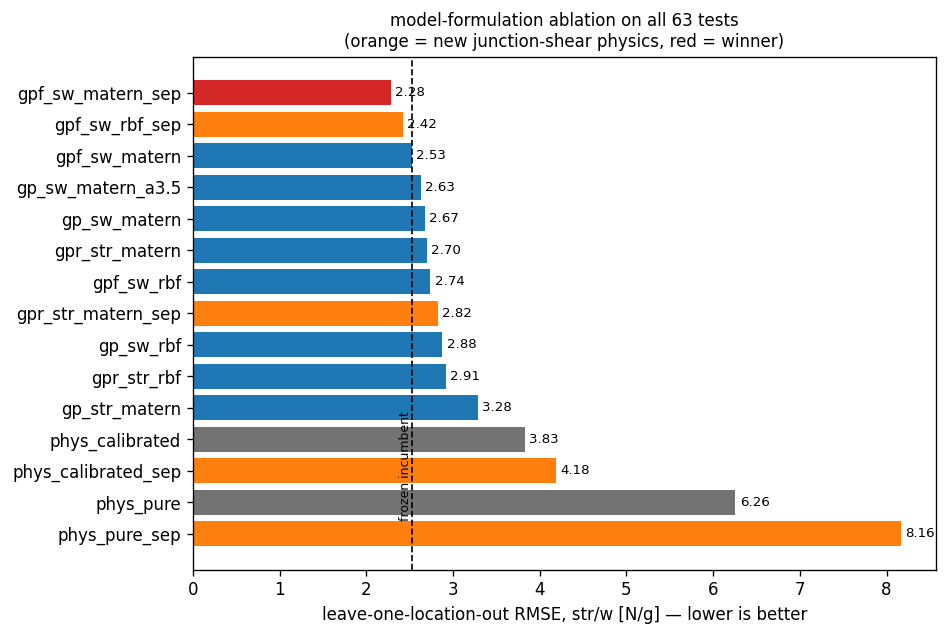

In [4]:
def metrics(y_true, y_pred, prefix=""):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    err = y_pred - y_true
    ss = np.sum((y_true - y_true.mean())**2)
    return {prefix + "rmse": float(np.sqrt(np.mean(err**2))),
            prefix + "mae": float(np.mean(np.abs(err))),
            prefix + "mape_pct": float(np.mean(np.abs(err / y_true)) * 100),
            prefix + "r2": float(1 - np.sum(err**2)/ss)}

locs = allt["loc"].unique()

def lolo_sw(kw):
    """Leave-one-location-out str/w predictions for one zoo entry."""
    preds = np.zeros(len(allt))
    for L in locs:
        te = (allt["loc"] == L).values
        mdl = BeamModel(**kw).fit(allt[~te])
        _, sw = mdl.predict(allt.b.values[te], allt.H.values[te])
        preds[te] = sw
    return preds

rows = []
for name, kw in ZOO.items():
    preds = lolo_sw(kw)
    rows.append({"model": name, **metrics(allt.sw_true, preds, "sw_")})
    print(f"{name:22s} LOLO sw RMSE {rows[-1]['sw_rmse']:.3f}  "
          f"MAPE {rows[-1]['sw_mape_pct']:.2f}%  R2 {rows[-1]['sw_r2']:+.3f}")

tbl = pd.DataFrame(rows).sort_values("sw_rmse").reset_index(drop=True)
winner = tbl.iloc[0]
old_best = tbl[~tbl.model.str.endswith("_sep")].iloc[0]
print(f"\nWINNER: {winner.model}  (LOLO sw RMSE {winner.sw_rmse:.3f} N/g on {len(allt)} tests)")
print(f"best OLD-physics entry: {old_best.model} at {old_best.sw_rmse:.3f}  "
      f"(this is the frozen class GT; gt_model_choice.json records 2.525)")
print(f"head-to-head, same model, only the shear physics swapped:")
for base in ["gpf_sw_matern", "gpf_sw_rbf", "gpr_str_matern", "phys_pure", "phys_calibrated"]:
    o = tbl.loc[tbl.model == base, "sw_rmse"].iloc[0]
    n = tbl.loc[tbl.model == base + "_sep", "sw_rmse"].iloc[0]
    verdict = "NEW better" if n < o else "OLD better"
    print(f"  {base:18s} OLD {o:6.3f}  ->  NEW {n:6.3f}   ({verdict}, {100*(n-o)/o:+.1f}%)")

# the leak plain LOO would have hidden
print("\nplain LOO vs LOLO (the repeat leak):")
for name in ["gpf_sw_matern_sep", "gpf_sw_matern", "gp_sw_matern"]:
    preds = np.zeros(len(allt))
    for i in range(len(allt)):
        mdl = BeamModel(**ZOO[name]).fit(allt.drop(allt.index[i]))
        _, sw = mdl.predict(allt.b.iloc[i], allt.H.iloc[i])
        preds[i] = sw[0]
    loo_rmse = np.sqrt(np.mean((preds - allt.sw_true.values)**2))
    lolo_rmse = tbl.loc[tbl.model == name, "sw_rmse"].iloc[0]
    print(f"  {name:18s} plain LOO {loo_rmse:.3f}  vs  LOLO {lolo_rmse:.3f} N/g")

# how much does the tau_i choice actually matter?
print("\ntau_i sensitivity for gpf_sw_matern_sep (LOLO sw RMSE):")
tau_rows = []
for lbl, tv in [("17.45 campaign (4 seps)", TAU_I_CAMPAIGN),
                ("14.56 pooled (9 seps)", TAU_I_POOLED),
                ("11.40 literature ILSS", TAU_I_LIT)]:
    r = np.sqrt(np.mean((lolo_sw(dict(variant="gpf_sw", kernel_kind="matern",
                                      shear="new", tau_i=tv))
                         - allt.sw_true.values)**2))
    tau_rows.append((lbl, r))
    print(f"  tau_i = {lbl:24s} {r:.3f}   (OLD physics: {old_best.sw_rmse:.3f})")
print("  -> every tau_i tested beats the OLD formulation, including the leak-free\n"
      "     literature value: the win is the shear MODEL, not the fitted constant.")

fig, ax = plt.subplots(figsize=(8, 5.4))
t2 = tbl.iloc[::-1]
cols = ["tab:red" if m == winner.model else
        ("tab:orange" if m.endswith("_sep") else
         ("0.45" if m.startswith("phys") else "tab:blue")) for m in t2.model]
ax.barh(t2.model, t2.sw_rmse, color=cols)
for y, (m, v) in enumerate(zip(t2.model, t2.sw_rmse)):
    ax.annotate(f"{v:.2f}", (v + 0.05, y), va="center", fontsize=8)
ax.axvline(old_best.sw_rmse, color="k", ls="--", lw=1)
ax.annotate("frozen incumbent", (old_best.sw_rmse, 0.4), fontsize=7.5,
            rotation=90, va="bottom", ha="right")
ax.set_xlabel("leave-one-location-out RMSE, str/w [N/g] — lower is better")
ax.set_title(f"model-formulation ablation on all {len(allt)} tests\n"
             "(orange = new junction-shear physics, red = winner)", fontsize=10)
plt.tight_layout(); plt.show()

## 4. What the winner is, and how stable this choice has been

**`gpf_sw_matern_sep`** — the same formulation as the frozen incumbent, on the
new shear physics. Precisely: a GP with inputs `(b, H_web, log P_phys, stab)`,
where `P_phys = min(P_bend, P_sep(τᵢ), P_LTB(k=0.33))`, `P_sep` is the
flange–web junction shear-flow capacity at τᵢ = 17.45 MPa, and
`stab = P_LTB/P_bend`. The target is `log(strength / estimated mass)`. The
kernel is Constant × Matérn(ν = 2.5) with per-dimension length scales,
`alpha = 0.03²`, z-scored inputs, mean-centered target, fixed seed.

**What the swap bought, and what it did not.** The model *family* did not
change — the same GP, target, and kernel still win; only the physics feature
improved. That is the convenient outcome: no student-facing lane structure
changes. The head-to-head table splits cleanly, and the split is the
interesting result:

| lane | how it uses `P_phys` | OLD → NEW |
|---|---|---|
| `gpf_sw_matern` | `log P_phys` as an **input feature** | 2.53 → **2.29** ✔ −9.5% |
| `gpf_sw_rbf` | `log P_phys` as an **input feature** | 2.74 → **2.42** ✔ −11.7% |
| `gpr_str_matern` | physics as a **multiplicative baseline** | 2.70 → 2.82 ✘ +4.5% |
| `phys_calibrated` | physics × one scale | 3.83 → 4.18 ✘ +9.2% |
| `phys_pure` | physics **as the prediction** | 6.26 → 8.16 ✘ +30.4% |

* **Feature lanes improve; baseline lanes degrade.** Every model that takes
  the physics as a *feature* got better; every model that takes it as a
  *prediction to be scaled* got worse. The mechanism is one number: the old
  inverse-square surrogate applied an extra knockdown to *every* beam, which
  accidentally compensated for σ_y = 76 MPa over-predicting flexural capacity
  by ~13% (median measured/predicted: 0.91 old vs 0.87 new). Retiring the
  surrogate removes that error cancellation and exposes the flexure bias, and
  a model that multiplies through the physics inherits the bias directly. A GP
  with the physics as a feature does not care — it fits its own correction and
  only wants the feature to have the right *shape and mode structure*, which
  is exactly what the junction-shear model fixes. In short: **the old model
  was more accurate for a reason that was not shear**, and the new one is
  right about shape while wrong by a scale factor the GP absorbs.
* **The honest fix for the baseline lanes is calibrated σ_y**, not a shear
  term on the wrong plane — which is exactly what Pre-lab 1 has students do
  (their `phys` lane fits σ_y, k, and now τᵢ). The `phys_*` rows here are
  deliberately *uncalibrated* so the GT does not depend on the class's
  calibration exercise, which is why they show the bias raw.
* **τᵢ barely matters to the GT** (2.285 / 2.317 / 2.390 at 17.45 / 14.56 /
  11.40 MPa — all beating 2.525). The leak-free literature value wins too, so
  the improvement is the shear *model*, not the fitted constant.

**Honesty about stability.** The winner has moved as the data grew:

| data state | winner |
|---|---|
| 43 beams (before beam 23's trace was recovered) | `gpf_sw_rbf` |
| 44 beams, plain LOOCV | `gp_sw_matern` |
| 63 tests, leave-one-location-out | `gpf_sw_matern` |
| 63 tests, LOLO, both shear models scored | `gpf_sw_matern_sep` |

Read the ablation bars accordingly: the top GP variants sit within a few
tenths of a N/g of each other, and single influential beams have reordered
them before. What has stayed stable across every re-evaluation: (1) a GP beats
pure or calibrated physics by a wide margin, (2) the str/w target beats the
raw-strength target, and (3) physics features help most at the edges of the
data. The class-facing consequences of swapping among the top two or three
GPs are small.

**Re-freezing is a separate decision — not taken here.** The frozen class
values in `ground_truth.py` still derive from the OLD-physics
`gpf_sw_matern`. The cell below fits both GTs and reports what adopting the
challenger would move. Adopting it means re-freezing the class query values
and rebuilding the student notebooks (`run13`), so it wants sign-off first.

GT optimum inside the student box, OLD physics (frozen GT) : 40.38 N/g at (1.78, 12.40)
GT optimum inside the student box, NEW physics (challenger): 40.12 N/g at (1.83, 12.10)

What re-freezing would move — GT means at the two frozen class designs:
design                     frozen        OLD refit   NEW (challenger)
equation beam      37.64 N/g       37.64 N/g        37.65 N/g
                   483.0 N         483.0 N          483.1 N   (+0.0% vs refit)
GP beam            38.12 N/g       38.12 N/g        37.69 N/g
                   509.7 N         510.2 N          504.4 N   (-1.1% vs refit)

(the OLD-refit column reproduces the frozen record, confirming the pipeline;
 the NEW column is what adopting the shear model would require re-freezing.)


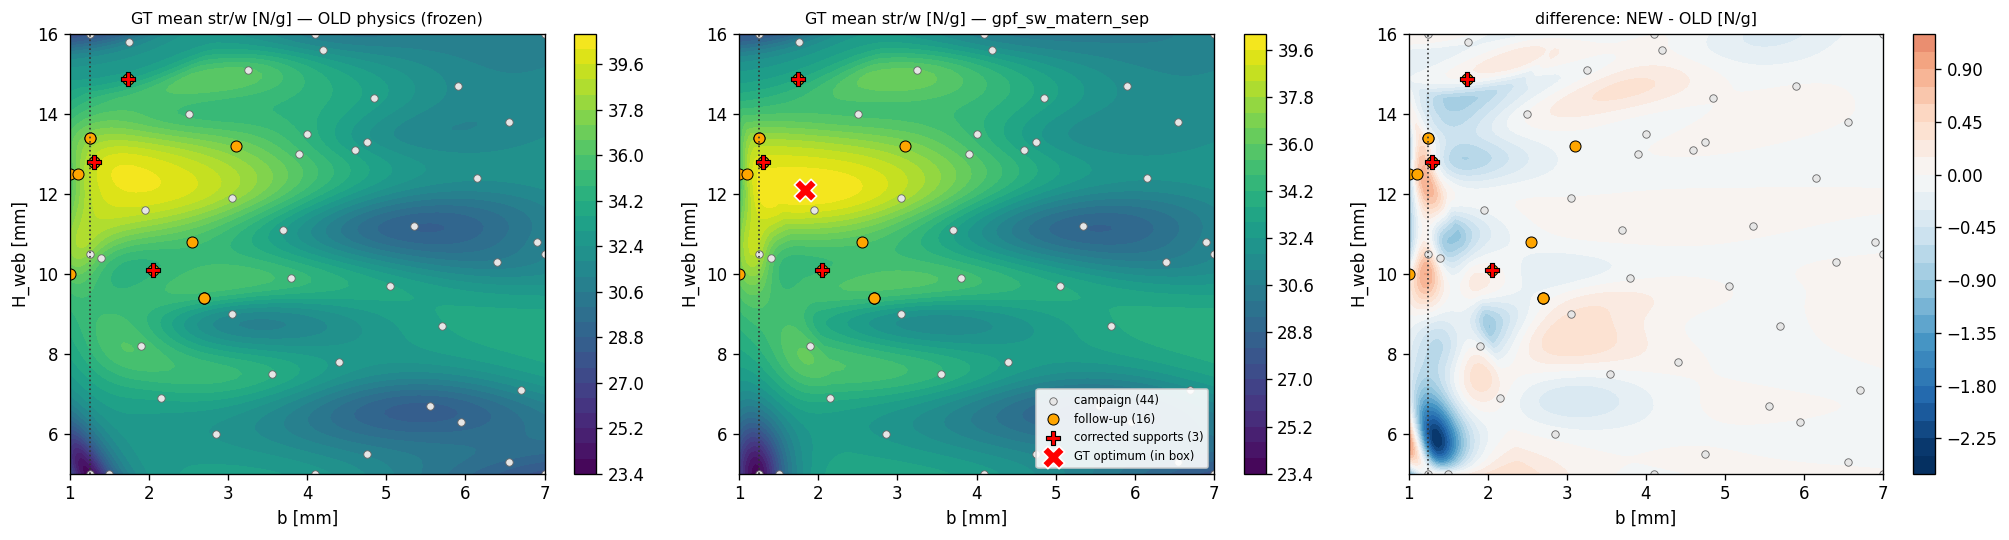

In [5]:
GT_old = BeamModel(**ZOO["gpf_sw_matern"]).fit(allt)       # frozen incumbent
GT_new = BeamModel(**ZOO[winner.model]).fit(allt)          # challenger

bg = np.linspace(1.0, B_HI, 124); Hg = np.linspace(H_LO, H_HI, 111)
BB, HH = np.meshgrid(bg, Hg)

def surf(GT):
    _, SWf, SIGf = GT.predict(BB.ravel(), HH.ravel(), return_std=True)
    return SWf.reshape(BB.shape), SIGf.reshape(BB.shape)

SW_o, SIG_o = surf(GT_old)
SW, SIG = surf(GT_new)

def optimum(SW):
    io = np.unravel_index(np.argmax(np.where(BB >= B_LO, SW, -np.inf)), SW.shape)
    return SW[io], BB[io], HH[io], io

for lbl, S in [("OLD physics (frozen GT)", SW_o), ("NEW physics (challenger)", SW)]:
    v, bo, ho, _ = optimum(S)
    print(f"GT optimum inside the student box, {lbl:24s}: {v:.2f} N/g at ({bo:.2f}, {ho:.2f})")
_, _, _, io = optimum(SW)

print("\nWhat re-freezing would move — GT means at the two frozen class designs:")
bg60, Hg60 = np.linspace(B_LO, B_HI, 60), np.linspace(H_LO, H_HI, 60)
b_gp = bg60[np.argmin(np.abs(bg60 - 1.44))]; H_gp = Hg60[np.argmin(np.abs(Hg60 - 13.39))]
print(f"{'design':16s} {'frozen':>16s} {'OLD refit':>16s} {'NEW (challenger)':>18s}")
for (bq, Hq), label, frz_sw, frz_N in [((1.25, 13.40), "equation beam", 37.64, 483.0),
                                       ((b_gp, H_gp),  "GP beam",       38.12, 509.7)]:
    so, swo = GT_old.predict([bq], [Hq])
    sn, swn = GT_new.predict([bq], [Hq])
    print(f"{label:16s} {frz_sw:7.2f} N/g     {swo[0]:7.2f} N/g      {swn[0]:7.2f} N/g")
    print(f"{'':16s} {frz_N:7.1f} N       {so[0]:7.1f} N        {sn[0]:7.1f} N"
          f"   ({100*(sn[0]-so[0])/so[0]:+.1f}% vs refit)")
print("\n(the OLD-refit column reproduces the frozen record, confirming the pipeline;\n"
      " the NEW column is what adopting the shear model would require re-freezing.)")

fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
for a, Z, ttl in [(ax[0], SW_o, "GT mean str/w [N/g] — OLD physics (frozen)"),
                  (ax[1], SW, f"GT mean str/w [N/g] — {winner.model}"),
                  (ax[2], SW - SW_o, "difference: NEW - OLD [N/g]")]:
    cmap = "RdBu_r" if "difference" in ttl else "viridis"
    kw = dict(levels=30, cmap=cmap)
    if "difference" in ttl:
        m = np.abs(SW - SW_o).max(); kw.update(vmin=-m, vmax=m)
    cf = a.contourf(BB, HH, Z, **kw)
    plt.colorbar(cf, ax=a)
    old = allt[allt.source == "campaign"]; new = allt[allt.source == "followup"]
    a.scatter(old.b, old.H, s=20, c="0.9", edgecolor="0.4", lw=0.5, label="campaign (44)")
    a.scatter(new[new.tag != "PS"].b, new[new.tag != "PS"].H, s=44, c="orange",
              edgecolor="k", lw=0.6, label="follow-up (16)")
    a.scatter(new[new.tag == "PS"].b, new[new.tag == "PS"].H, s=80, marker="P",
              c="red", edgecolor="k", lw=0.7, label="corrected supports (3)")
    a.axvline(B_LO, color="0.2", ls=":", lw=1)
    a.set_xlabel("b [mm]"); a.set_ylabel("H_web [mm]"); a.set_title(ttl, fontsize=9.5)
ax[1].scatter([BB[io]], [HH[io]], marker="X", s=180, c="red", edgecolor="w",
              zorder=5, label="GT optimum (in box)")
ax[1].legend(fontsize=7, loc="lower right", framealpha=0.9)
plt.tight_layout(); plt.show()

## 5. Caveats that should travel with this model

1. **τᵢ is mildly circular, and it drifts.** The winning feature uses
   τᵢ = 17.45 MPa, back-calculated from four campaign separations that LOLO
   later hides — a small leak (one scalar, entering only a deterministic
   function of geometry, so no beam can be memorized through it). The τᵢ sweep
   in Section 3 is the check: the leak-free literature value (11.40 MPa) also
   beats the old formulation, so the win survives removing the circularity.
   Separately, τᵢ is a *printed-joint* property, not a material constant — it
   measured 15–21 MPa in the campaign and 11–15 MPa in later sessions, moving
   with print quality and support settings. The shear-model notebook
   recommends carrying it as a distribution; the GT uses a point value and
   lets the GP absorb the rest.
2. **The support-setting confound.** During the campaign, print supports were
   generating as individual lines instead of the intended zigzag. Three
   follow-up beams were printed with corrected supports (`PS`); the cell below
   compares each against same-geometry prints with the old supports. All three
   are weaker — consistently enough that it does not look like print-to-print
   noise — so a GT trained almost entirely on old-support beams may sit
   several percent **high in absolute newtons** for corrected-support prints.
   Three beams is a small sample and print session is confounded with the
   setting change; more PS replicates are on the list before anything
   depending on absolute strength is frozen. The *relative* landscape (where
   the good designs are) is less exposed. (The controlled 10-beam interleaved
   experiment that later resolved this — proper supports +7.2% and 5× more
   repeatable — lives in the staff pipeline, notebook 17.)
3. **The thin-web frontier is uncertain, and only the data knows how.** Of the
   follow-up probes below the box edge (b = 1.0–1.1), the taller-web ones
   carried well under what campaign-calibrated physics promises — failing by
   flange–web separation — while the shortest-web probe over-performed
   instead. The new shear model gives that mode a mechanism for the first
   time, which is much of why the physics-informed GPs improved; it does not
   make the frontier certain.
4. **Noise: 3.5% measured vs 3% assumed.** Compare the `gp_sw_matern` and
   `gp_sw_matern_a3.5` rows in the ablation — the difference is far below the
   resolution of this comparison, so the classroom 3% stands.
5. **Selection measures interpolation.** LOLO scores predictions at geometries
   surrounded by other tested geometries. Extrapolation quality outside the
   tested cloud is not scored — one reason the frozen class queries return GT
   values only at well-supported points.
6. **The GT embeds the physics it is scored with.** Because the winner takes
   `log P_phys` as a feature, the ground truth inherits our failure-mode
   assumptions (now including τᵢ and k = 0.33). This mildly flatters
   physics-informed variants in any downstream study that scores against this
   GT — a known limitation of using a PI model as the oracle, unchanged in
   kind by this update but worth restating now that the physics has moved.

In [6]:
# corrected-support (PS) beams vs same-geometry old-support prints
print("PS vs old-support prints, same geometry (z in units of pooled noise):")
zs = []
for (b, H) in add[add.proper_supports][["b", "H"]].itertuples(index=False):
    g = add[(add.b == b) & (add.H == H)]
    ps = g[g.proper_supports].iloc[0]
    old_N = list(g[~g.proper_supports].strength_N) + \
            list(camp[np.isclose(camp.b, b) & np.isclose(camp.H, H)].strength_N)
    dlog = np.log(ps.strength_N) - np.mean(np.log(old_N))
    z = dlog / sigma_pooled
    zs.append(z)
    print(f"  ({b}, {H}):  PS {ps.strength_N:.1f} N vs old mean {np.mean(old_N):.1f} N "
          f"(n={len(old_N)})  ->  {np.exp(dlog)*100-100:+.1f}%  (z = {z:+.2f})")
print(f"combined z = {sum(zs)/np.sqrt(len(zs)):+.2f}  (all three weaker)")

# the thin-web frontier: measured vs physics calibrated on the pre-frontier campaign
pc = BeamModel(variant="phys_cal").fit(allt[allt.source == "campaign"])
frontier = add[add.b <= 1.1]
print("\nthin-web frontier (below the b = 1.25 box edge):")
for _, r in frontier.iterrows():
    _, sw_pc = pc.predict([r.b], [r.H])
    print(f"  ({r.b}, {r.H}):  measured {r.sw:.1f} N/g   vs  campaign-calibrated "
          f"physics {sw_pc[0]:.1f} N/g   — {r.failure_note[:60]}")

PS vs old-support prints, same geometry (z in units of pooled noise):
  (1.3, 12.8):  PS 524.2 N vs old mean 558.2 N (n=4)  ->  -6.1%  (z = -1.81)
  (1.74, 14.88):  PS 376.1 N vs old mean 399.1 N (n=2)  ->  -5.7%  (z = -1.69)
  (2.05, 10.1):  PS 660.2 N vs old mean 747.5 N (n=1)  ->  -11.7%  (z = -3.58)
combined z = -4.09  (all three weaker)

thin-web frontier (below the b = 1.25 box edge):
  (1.0, 10.0):  measured 36.4 N/g   vs  campaign-calibrated physics 31.8 N/g   — Seperation of the top flange from the web. Vertical crack al
  (1.0, 12.5):  measured 34.4 N/g   vs  campaign-calibrated physics 41.7 N/g   — Seperation of the top flange from the web. Interface between
  (1.1, 12.5):  measured 38.5 N/g   vs  campaign-calibrated physics 42.3 N/g   — Vertical crack, however, it was toward the end of the beam, 


## Provenance

- **Data:** `data/ground_truth_B10_L150.csv` (44-beam campaign, with the
  recovered beam-23 trace and the 847.5 N duplicate resolved to beam 29) and
  `data/ibeam150_additional_tests.csv` (19 follow-up tests, 2026-07-08), both
  in this repo. Raw Instron traces live in the staff archive, not here.
- **The shear model** scored here as `_sep` is derived and defended in
  `ME323_Module1_Shear_Model_Selection_FACULTY.ipynb` (same folder), which
  carries the fracture-note evidence, the τᵢ back-calculation, the rejected
  pointwise von Mises alternative, and the supporting data extracts.
- **This notebook** distills the staff analysis pipeline (notebooks 15–16 of
  `me323/ibeam150_analysis/`, kept off the public repo) into a shareable,
  reproducible record. The full pipeline also covers the 847.5 N duplicate
  resolution, subset-design Monte Carlo studies, and the class dry run.
- **Consumption:** students never query this model. The two class-wide designs
  were evaluated once against the GT mean and the resulting numbers frozen
  into the student notebooks (staff record:
  `me323/Module1_drafts/ground_truth.py`). **Those frozen values still come
  from the OLD-physics GT**; adopting the challenger requires re-freezing them
  and rebuilding the student notebooks via `run13`.
- **Before go-live:** this notebook and both campaign CSVs come off the public
  repo so students cannot look up the answer surface.